In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pickle
from pathlib import Path
from IPython.display import Audio
import IPython.display as ipd
from scipy.io import wavfile
import tempfile
import os
import librosa
import pandas as pd
import seaborn as sns
import h5py
import mne
from scipy.stats import zscore
from mne_bids import BIDSPath, read_raw_bids
from matplotlib_venn import venn2,venn2_circles
from tqdm import tqdm

In [2]:
cm = 1/2.54
plt.rcParams['svg.fonttype'] = 'none'

fontdict = dict(fontsize=7)
fontsize = 7

red = '#A9373B'
blue = '#2369BD'
orange = '#CC8963'
green = '#009944'

stg_color = '#20B2AA'
smc_color = '#6A5ACD'
insula_color = '#D4AF37'

reds = sns.light_palette(red, as_cmap=True)
blues = sns.light_palette(blue, as_cmap=True)
oranges = sns.light_palette(orange, as_cmap=True)
greens = sns.light_palette(green, as_cmap=True)

recon_dir = '/cwork/ns458/ECoG_Recon/'
mne.viz.set_3d_backend('notebook')                    # MNE 3D in-notebook static backend
# text svg

Using notebook 3d backend.


In [3]:
SENTENCE_PT = '/cwork/ns458/BIDS-1.4_SentenceRep/BIDS/'

In [53]:
sub = 'D0060'
phase = 'baseline'
raw_pt = BIDSPath(
    root=os.path.join(SENTENCE_PT, 'derivatives', 'epoch(bipolar)'),
    datatype='epoch(raw)',
    subject=sub,
    suffix='raw',
    processing=phase,
    description='Repeat',
    extension='.h5',
    check=False
)

raw_pt = raw_pt.match()[0]
epochs = mne.read_epochs(raw_pt, preload=True)
epochs.crop(tmax=0)

Reading /cwork/ns458/BIDS-1.4_SentenceRep/BIDS/derivatives/epoch(bipolar)/sub-D0060/epoch(raw)/sub-D0060_task-SentenceRep_proc-baseline_desc-Repeat_raw.h5 ...
    Found the data of interest:
        t =   -1000.00 ...     500.00 ms
        0 CTF compensation matrices available


/hpc/home/ns458/coganlab/nanlinshi/tmp/ipykernel_3322397/3104095616.py:15: RuntimeWarning: This filename (/cwork/ns458/BIDS-1.4_SentenceRep/BIDS/derivatives/epoch(bipolar)/sub-D0060/epoch(raw)/sub-D0060_task-SentenceRep_proc-baseline_desc-Repeat_raw.h5) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs = mne.read_epochs(raw_pt, preload=True)


Not setting metadata
99 matching events found
No baseline correction applied
0 projection items activated


<EpochsFIF | 99 events (all good), -1 – 0 s (baseline off), ~297.4 MiB, data loaded,
 'Start/Listen/LS': 99>

Effective window size : 1.000 (s)

	Lower bounds below frequency-resolution have no effect (effective lower bound is the frequency resolution).
	Too low a limit may lead to overfitting noise as small bandwidth peaks.
	We recommend a lower bound of approximately 2x the frequency resolution.



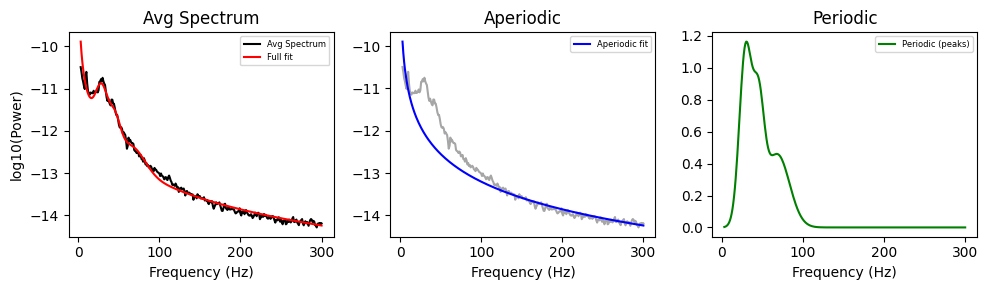

In [55]:
# ---- average spectrum across trials (same channel) ----
ch_idx = 20
sfreq = epochs.info['sfreq']

# get all trials for this channel: shape (n_trials, n_times)
xs = epochs.get_data()[:, ch_idx]
xs = xs - np.mean(xs, axis=-1, keepdims=True)

# compute PSD per-trial, then average
psd, freqs = psd_array_welch(
    xs, sfreq=sfreq, fmin=3, fmax=300,
    n_fft=min(2048, xs.shape[-1]), n_overlap=0
)
psd_mean = psd.mean(axis=0)      # (n_freqs,)

# fit specparam on averaged spectrum
fm_avg = SpectralModel(peak_width_limits=[1, 30], max_n_peaks=3, min_peak_height=0.5)
fm_avg.fit(freqs, psd_mean)

model_avg = fm_avg.results.model
ap_fit_avg = model_avg.get_component('aperiodic', space='log')
full_fit_avg = model_avg.get_component('full', space='log')
peak_fit_avg = model_avg.get_component('peak', space='log')

# ---- visualization ----
fig, axes = plt.subplots(1, 3, figsize=(10, 3))

axes[0].plot(freqs, np.log10(psd_mean), color='k', label='Avg Spectrum')
axes[0].plot(freqs, full_fit_avg, color='r', label='Full fit')
axes[0].set_title('Avg Spectrum')
axes[0].set_xlabel('Frequency (Hz)')
axes[0].set_ylabel('log10(Power)')
axes[0].legend(fontsize=6)


axes[1].plot(freqs, np.log10(psd_mean), color='k', alpha=0.35)
axes[1].plot(freqs, ap_fit_avg, color='b', label='Aperiodic fit')
axes[1].set_title('Aperiodic')
axes[1].set_xlabel('Frequency (Hz)')
axes[1].legend(fontsize=6)

axes[2].plot(freqs, peak_fit_avg, color='g', label='Periodic (peaks)')
axes[2].set_title('Periodic')
axes[2].set_xlabel('Frequency (Hz)')
axes[2].legend(fontsize=6)

fig.tight_layout()